In [1]:
# Cell 1
# ─── Install dependencies ───────────────────────────────────────────────────
!pip install -q fastapi uvicorn nest-asyncio pyngrok pandas numpy scikit-learn torch matplotlib
print("✅ All packages installed.")

✅ All packages installed.


In [2]:
# Cell 2
# ─── Imports & Global Config ────────────────────────────────────────────────
import os, json, warnings
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_PATH  = "us_programs_dataset.csv"
MODEL_DIR  = Path("model_artifacts_us")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "us_eligibility_nn.pt"
META_PATH  = MODEL_DIR / "us_eligibility_meta.json"

print(f"Model artifacts → {MODEL_DIR.resolve()}")

Using device: cpu
Model artifacts → /content/model_artifacts_us


In [3]:
# Cell 3
# ─── Load & Inspect Dataset ─────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, on_bad_lines="skip", engine="python")
df_raw.columns = df_raw.columns.str.strip().str.lower()

print("=" * 65)
print("📂  US PROGRAMS DATASET OVERVIEW")
print("=" * 65)
print(f"  Shape             : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Missing values    : {df_raw.isnull().sum().sum()}")
print(f"  Universities      : {df_raw['university_name'].nunique()}")
print(f"  Program levels    : {df_raw['program_level'].value_counts().to_dict()}")
print(f"  Degree types      : {sorted(df_raw['degree_type'].unique().tolist())}")
print(f"  Program categories: {sorted(df_raw['program_category'].unique().tolist())}")
print(f"\n  SAT range         : {df_raw['sat_min'].min()} – {df_raw['sat_max'].max()}")
print(f"  ACT range         : {df_raw['act_min'].min()} – {df_raw['act_max'].max()}")
print(f"  GPA req range     : {df_raw['min_gpa'].min()} – {df_raw['min_gpa'].max()}")
print(f"  IELTS req range   : {df_raw['min_ielts_overall'].min()} – {df_raw['min_ielts_overall'].max()}")
print(f"  TOEFL req range   : {df_raw['toefl_score'].min()} – {df_raw['toefl_score'].max()}")
print(f"  Tuition range     : ${df_raw['tuition_fee_usd'].min():,} – ${df_raw['tuition_fee_usd'].max():,}")
print(f"  GRE required      : {df_raw['gre_required'].value_counts().to_dict()}")
print(f"  Work experience   : {df_raw['work_experience_required'].value_counts().to_dict()}")
print("=" * 65)

df_raw.head(3)

📂  US PROGRAMS DATASET OVERVIEW
  Shape             : 107,369 rows × 32 columns
  Missing values    : 92350
  Universities      : 2028
  Program levels    : {'Undergraduate': 66412, 'Masters': 20678, 'Doctoral': 15655, 'Professional': 4624}
  Degree types      : ['AA', 'AAS', 'AS', 'BA', 'BArch', 'BBA', 'BFA', 'BS', 'DDS', 'JD', 'MA', 'MBA', 'MD', 'MEng', 'MS', 'PhD', 'PharmD']
  Program categories: ['Architecture', 'Arts', 'Business & Economics', 'Computer Science', 'Education', 'Engineering', 'Health Sciences', 'Humanities', 'Natural Sciences', 'Professional', 'Social Sciences']

  SAT range         : 780 – 1580
  ACT range         : 12 – 36
  GPA req range     : 2.5 – 3.7
  IELTS req range   : 5.5 – 8.0
  TOEFL req range   : 61 – 109
  Tuition range     : $600 – $72,100
  GRE required      : {'Not Required': 90793, 'Optional': 15996, 'Yes': 580}
  Work experience   : {'Not Required': 102377, 'Preferred': 4624, '2+ years preferred': 240, '3+ years required': 128}


,university_name,state,city,location,institution_type,country,sat_min,sat_max,sat_avg,act_min,...,toefl_score,duolingo_score,min_gpa,gre_required,min_gre_score,work_experience_required,field_requirements,application_deadline,university_url,qs_world_ranking
0,Princeton University,NJ,Princeton,"Princeton, NJ",Private University (Nonprofit),USA,1510,1580,1540,34,...,100,120,3.4,Not Required,Not Required,Not Required,High school diploma or equivalent; standard ad...,January 1,https://www.princeton.edu/,25
1,Princeton University,NJ,Princeton,"Princeton, NJ",Private University (Nonprofit),USA,1510,1580,1540,34,...,100,120,3.4,Not Required,Not Required,Not Required,High school diploma or equivalent; standard ad...,January 1,https://www.princeton.edu/,25
2,Princeton University,NJ,Princeton,"Princeton, NJ",Private University (Nonprofit),USA,1510,1580,1540,34,...,100,120,3.4,Not Required,Not Required,Not Required,High school diploma or equivalent; standard ad...,January 1,https://www.princeton.edu/,25


In [4]:
# Cell 4
# ─── Feature Engineering & Label Creation ───────────────────────────────────
df = df_raw.copy()

# ── Drop Duolingo (no Duolingo in this model) ────────────────────────────────
df.drop(columns=["duolingo_score"], errors="ignore", inplace=True)

# ── Encode GRE required: 'Yes' → 1, 'Optional' → 0.5, else → 0 ─────────────
df["gre_required_flag"] = df["gre_required"].map(
    {"Yes": 1.0, "Optional": 0.5, "Not Required": 0.0}
).fillna(0.0)

# ── Encode work experience: map string categories to numeric years ────────────
WORK_MAP = {
    "Not Required":        0.0,
    "Preferred":           1.0,
    "2+ years preferred":  2.0,
    "3+ years required":   3.0,
}
df["work_exp_years"] = df["work_experience_required"].map(WORK_MAP).fillna(0.0)

# ── min_gre_score is all "Not Required"/"Not Specified" → treat as 0 ─────────
df["min_gre_score_num"] = 0.0

# ── Handle qs_world_ranking: ranges like '1001-1200' → take lower bound ──────
def parse_qs(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.endswith("+"):            # e.g. '1401+'
        return float(val[:-1])
    if "-" in val:                   # e.g. '1001-1200', '701-710'
        return float(val.split("-")[0])
    try:
        return float(val)
    except ValueError:
        return np.nan

df["qs_rank"] = df["qs_world_ranking"].apply(parse_qs)
# Universities without a QS rank get 9999 (ranked last / unknown)
df["qs_rank"].fillna(9999, inplace=True)

# ── Numeric cols that need coercion ──────────────────────────────────────────
NUM_COLS = [
    "sat_min", "sat_max", "sat_avg",
    "act_min", "act_max", "act_avg",
    "min_ielts_overall", "min_ielts_band",
    "toefl_score", "min_gpa",
    "tuition_fee_usd", "program_duration_years",
]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c].fillna(df[c].median(), inplace=True)

# ── Scholarship flag ──────────────────────────────────────────────────────────
df["scholarship_flag"] = (
    df["scholarship_available"].astype(str).str.strip().str.lower() == "yes"
).astype(int)

# ── Simulate applicant pool ───────────────────────────────────────────────────
np.random.seed(SEED)
n = len(df)

sim_sat   = np.random.normal(1150, 150, n).clip(400,  1600)
sim_act   = np.random.normal(24,   5,   n).clip(1,    36)
sim_gpa   = np.random.normal(3.2,  0.4, n).clip(0.0,  4.0)
sim_ielts = np.random.normal(6.5,  0.6, n).clip(4.0,  9.0)
sim_toefl = np.random.normal(90,   12,  n).clip(40,   120)
sim_gre   = np.random.normal(310,  10,  n).clip(260,  340)
sim_work  = np.random.uniform(0,    4,  n)               # years of work exp

# ── Delta features (positive = student exceeds requirement) ──────────────────
df["delta_sat"]   = (sim_sat   - df["sat_avg"])            / 400.0
df["delta_act"]   = (sim_act   - df["act_avg"])            / 18.0
df["delta_gpa"]   = (sim_gpa   - df["min_gpa"])            / 1.5
df["delta_ielts"] = (sim_ielts - df["min_ielts_overall"])  / 3.0
df["delta_toefl"] = (sim_toefl - df["toefl_score"])        / 50.0
df["delta_gre"]   = np.where(
    df["gre_required_flag"] > 0,
    (sim_gre - 300.0) / 40.0,   # 300 is a safe baseline; min_gre_score is N/A
    0.0
)
df["delta_work"]  = (sim_work - df["work_exp_years"]) / 4.0

# ── Binary eligibility label ──────────────────────────────────────────────────
# Student meets criterion if simulated value >= requirement
sat_ok   = (sim_sat   >= df["sat_avg"].values).astype(int)
act_ok   = (sim_act   >= df["act_avg"].values).astype(int)
gpa_ok   = (sim_gpa   >= df["min_gpa"].values).astype(int)
ielts_ok = (sim_ielts >= df["min_ielts_overall"].values).astype(int)
toefl_ok = (sim_toefl >= df["toefl_score"].values).astype(int)
gre_ok   = np.where(
    df["gre_required_flag"].values > 0,
    (sim_gre >= 300).astype(int),   # bare minimum baseline
    1                                # GRE not required → always ok
)
work_ok  = (sim_work >= df["work_exp_years"].values).astype(int)

met            = sat_ok + act_ok + gpa_ok + ielts_ok + toefl_ok + gre_ok + work_ok
df["eligible"] = (met >= 5).astype(int)   # eligible if ≥5/7 criteria met

print(f"Label distribution:\n{df['eligible'].value_counts()}")
print(f"Eligibility rate  : {df['eligible'].mean()*100:.1f}%")

# ── Encode categoricals ───────────────────────────────────────────────────────
CAT_COLS = ["degree_type", "program_level", "program_category"]
label_encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    df[c + "_enc"] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

print(f"\nDataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns")

Label distribution:
eligible
1    71590
0    35779
Name: count, dtype: int64
Eligibility rate  : 66.7%

Dataset ready: 107,369 rows × 47 columns


In [5]:
# Cell 5
# ─── Build Feature Matrix, Split & Scale ────────────────────────────────────
FEATURE_COLS = [
    "delta_sat", "delta_act", "delta_gpa",
    "delta_ielts", "delta_toefl", "delta_gre", "delta_work",
    "tuition_fee_usd", "program_duration_years",
    "scholarship_flag", "qs_rank", "gre_required_flag",
]
ENC_COLS     = [c + "_enc" for c in CAT_COLS]
ALL_FEATURES = FEATURE_COLS + ENC_COLS
print(f"Features used ({len(ALL_FEATURES)}): {ALL_FEATURES}")

X = df[ALL_FEATURES].values.astype(np.float32)
y = df["eligible"].values.astype(np.float32)

# Force-clean any NaN / Inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
assert not np.isnan(X).any() and not np.isinf(X).any(), "❌ Still NaN/Inf in X"
assert set(np.unique(y)).issubset({0.0, 1.0}),          "❌ Labels must be 0 or 1"
print("✅ Data checks passed")

# ── Split: 70 / 15 / 15 ──────────────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ── Tensors & DataLoaders ─────────────────────────────────────────────────────
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train,  dtype=torch.float32)
Xv  = torch.tensor(X_val,   dtype=torch.float32)
yv  = torch.tensor(y_val,   dtype=torch.float32)
Xts = torch.tensor(X_test,  dtype=torch.float32)
yts = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xv,  yv),  batch_size=256)

Features used (15): ['delta_sat', 'delta_act', 'delta_gpa', 'delta_ielts', 'delta_toefl', 'delta_gre', 'delta_work', 'tuition_fee_usd', 'program_duration_years', 'scholarship_flag', 'qs_rank', 'gre_required_flag', 'degree_type_enc', 'program_level_enc', 'program_category_enc']
✅ Data checks passed
Train: 75,158  |  Val: 16,105  |  Test: 16,106


In [6]:
# Cell 6
# ─── Model Definition & Training ────────────────────────────────────────────
class EligibilityNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,  32),        nn.ReLU(),
            nn.Linear(32,  1),         nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = EligibilityNet(len(ALL_FEATURES)).to(DEVICE)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

EPOCHS    = 60
LR        = 3e-4
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history       = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb).clamp(1e-7, 1 - 1e-7)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(Xtr)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds  = model(xb).clamp(1e-7, 1 - 1e-7)
            val_loss += criterion(preds, yb).item() * len(xb)
            correct  += ((preds >= 0.5) == yb.bool()).sum().item()
    val_loss /= len(Xv)
    val_acc   = correct / len(Xv)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_acc={val_acc:.4f}")

print(f"\n✅ Best val_loss: {best_val_loss:.4f}  |  Model saved → {MODEL_PATH}")

EligibilityNet(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
    (15): Sigmoid()
  )
)
Total parameters: 48,257
Epoch   1/60  train_loss=0.3603  val_loss=0.2483  val_acc=0.8916
Epoch  10/60  train_loss=0.1786  val_loss=0.1210  val_acc=0.9560
Epoch  20/60  train_los

🧪  TEST SET EVALUATION
              precision    recall  f1-score   support

Not Eligible       0.98      0.97      0.97      5367
    Eligible       0.98      0.99      0.99     10739

    accuracy                           0.98     16106
   macro avg       0.98      0.98      0.98     16106
weighted avg       0.98      0.98      0.98     16106

ROC-AUC: 0.9986


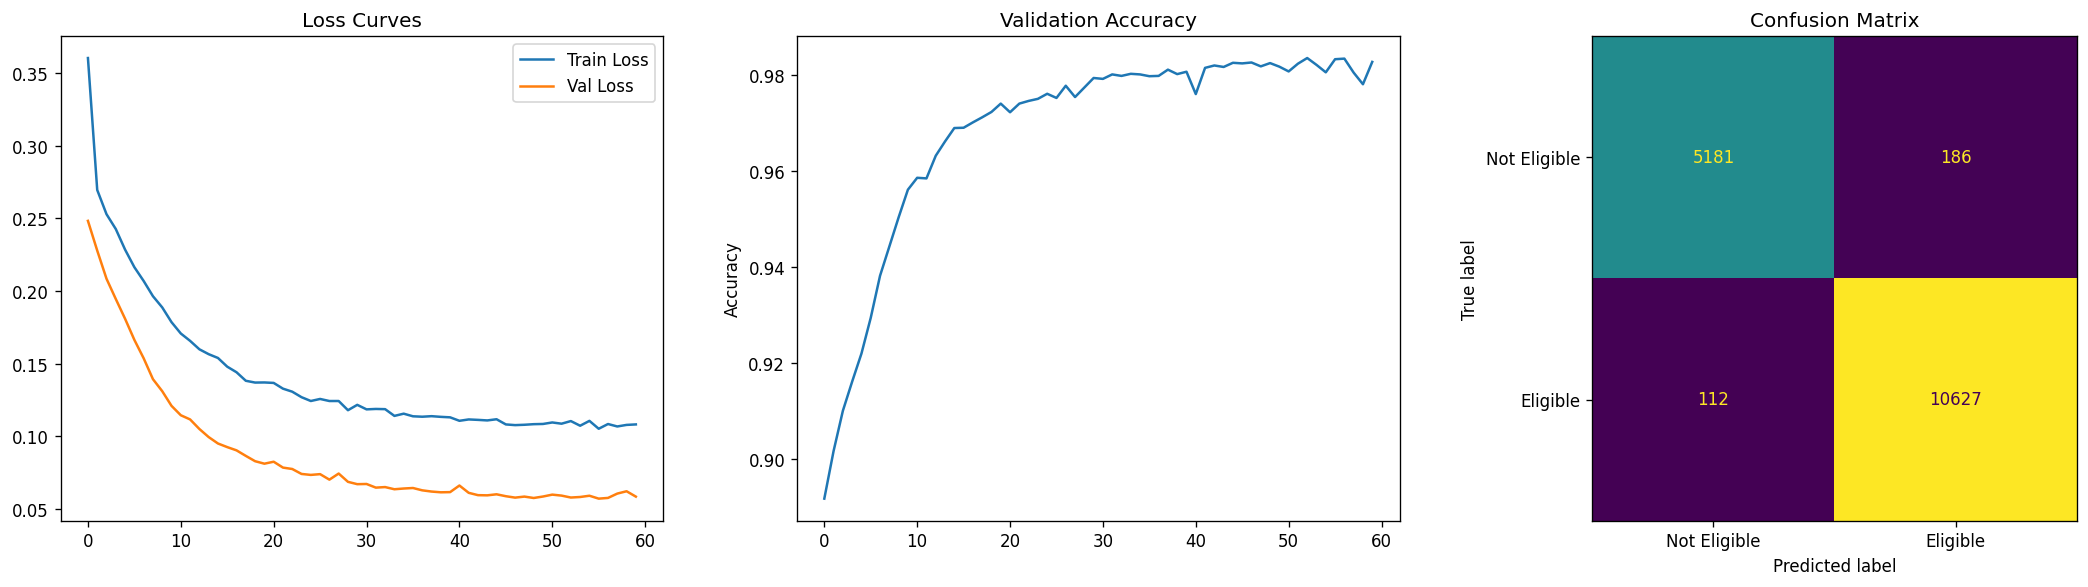

📈 Plot saved.


In [7]:
# Cell 7
# ─── Evaluation on Test Set ─────────────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

with torch.no_grad():
    y_prob = model(Xts.to(DEVICE)).cpu().numpy()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 55)
print("🧪  TEST SET EVALUATION")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Not Eligible", "Eligible"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss Curves"); axes[0].legend()

axes[1].plot(history["val_acc"])
axes[1].set_title("Validation Accuracy"); axes[1].set_ylabel("Accuracy")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Eligible", "Eligible"]).plot(
    ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluation.png", dpi=150)
plt.show()
print("📈 Plot saved.")

In [8]:
# Cell 8
# ─── Save Metadata & Processed Dataset ──────────────────────────────────────
df.to_csv(MODEL_DIR / "us_programs.csv", index=False)

meta = {
    "feature_cols":       ALL_FEATURES,
    "cat_cols":           CAT_COLS,
    "scaler_mean":        scaler.mean_.tolist(),
    "scaler_scale":       scaler.scale_.tolist(),
    "label_encoders":     {k: list(v.classes_) for k, v in label_encoders.items()},
    "degree_types":       sorted(df["degree_type"].unique().tolist()),
    "program_levels":     sorted(df["program_level"].unique().tolist()),
    "program_categories": sorted(df["program_category"].unique().tolist()),
    "sat_range":          [int(df["sat_avg"].min()),             int(df["sat_avg"].max())],
    "act_range":          [int(df["act_avg"].min()),             int(df["act_avg"].max())],
    "gpa_range":          [float(df["min_gpa"].min()),           float(df["min_gpa"].max())],
    "ielts_range":        [float(df["min_ielts_overall"].min()), float(df["min_ielts_overall"].max())],
    "toefl_range":        [int(df["toefl_score"].min()),         int(df["toefl_score"].max())],
    "tuition_range":      [int(df["tuition_fee_usd"].min()),     int(df["tuition_fee_usd"].max())],
    "qs_rank_range":      [float(df["qs_rank"].min()),           float(df["qs_rank"].max())],
}

with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("✅ Metadata saved:")
for k, v in meta.items():
    display_v = v if not isinstance(v, list) or len(v) <= 6 else str(v[:4]) + "..."
    print(f"  {k}: {display_v}")

# ── Verify saved CSV ──────────────────────────────────────────────────────────
df_check = pd.read_csv(MODEL_DIR / "us_programs.csv")
print(f"\nSaved CSV shape       : {df_check.shape}")
print(f"program_level unique  : {df_check['program_level'].str.strip().unique().tolist()}")
print(f"degree_type unique    : {df_check['degree_type'].str.strip().unique().tolist()}")
print(f"program_category count: {df_check['program_category'].nunique()}")
print(f"QS rank non-null      : {(df_check['qs_rank'] < 9999).sum():,}")

✅ Metadata saved:
  feature_cols: ['delta_sat', 'delta_act', 'delta_gpa', 'delta_ielts']...
  cat_cols: ['degree_type', 'program_level', 'program_category']
  scaler_mean: [0.04733058121072907, -0.0012696992232428097, 0.26342091143378166, -0.023451071276992138]...
  scaler_scale: [0.5103186000109601, 0.347469911280033, 0.3071001658689013, 0.2543134523000113]...
  label_encoders: {'degree_type': ['AA', 'AAS', 'AS', 'BA', 'BArch', 'BBA', 'BFA', 'BS', 'DDS', 'JD', 'MA', 'MBA', 'MD', 'MEng', 'MS', 'PhD', 'PharmD'], 'program_level': ['Doctoral', 'Masters', 'Professional', 'Undergraduate'], 'program_category': ['Architecture', 'Arts', 'Business & Economics', 'Computer Science', 'Education', 'Engineering', 'Health Sciences', 'Humanities', 'Natural Sciences', 'Professional', 'Social Sciences']}
  degree_types: ['AA', 'AAS', 'AS', 'BA']...
  program_levels: ['Doctoral', 'Masters', 'Professional', 'Undergraduate']
  program_categories: ['Architecture', 'Arts', 'Business & Economics', 'Computer S

In [9]:
# Cell 9
# ─── FastAPI App + Scoring Logic ─────────────────────────────────────────────
import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Optional

nest_asyncio.apply()

# ── Load artefacts ────────────────────────────────────────────────────────────
PROGRAMS_DF = pd.read_csv(MODEL_DIR / "us_programs.csv")
with open(META_PATH) as f:
    META = json.load(f)

# Reload scaler and encoders from saved meta
scaler_api = StandardScaler()
scaler_api.mean_  = np.array(META["scaler_mean"])
scaler_api.scale_ = np.array(META["scaler_scale"])

le_api: dict[str, LabelEncoder] = {}
for col, classes in META["label_encoders"].items():
    le = LabelEncoder()
    le.classes_ = np.array(classes)
    le_api[col] = le

model_api = EligibilityNet(len(META["feature_cols"])).to(DEVICE)
model_api.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model_api.eval()

# ── Pydantic schema ────────────────────────────────────────────────────────────
class StudentProfile(BaseModel):
    sat_score:          Optional[int]   = Field(None, ge=400,  le=1600)
    act_score:          Optional[int]   = Field(None, ge=1,    le=36)
    gpa:                float           = Field(...,  ge=0.0,  le=4.0)
    ielts_overall:      Optional[float] = Field(None, ge=4.0,  le=9.0)
    toefl_score:        Optional[int]   = Field(None, ge=40,   le=120)
    gre_score:          Optional[int]   = Field(None, ge=260,  le=340)
    work_exp_years:     Optional[float] = Field(0.0,  ge=0.0)
    program_level:      str             = "Undergraduate"
    program_category:   Optional[str]   = None
    degree_type:        Optional[str]   = None
    scholarship_only:   bool            = False
    max_tuition_usd:    Optional[int]   = None
    top_n:              int             = Field(10,   ge=1,    le=50)

# ── Level normalisation map ────────────────────────────────────────────────────
LEVEL_MAP = {
    "undergraduate": "Undergraduate",
    "bachelors":     "Undergraduate",
    "bachelor":      "Undergraduate",
    "ug":            "Undergraduate",
    "masters":       "Masters",
    "master":        "Masters",
    "graduate":      "Masters",
    "ms":            "Masters",
    "mba":           "Masters",
    "doctoral":      "Doctoral",
    "phd":           "Doctoral",
    "professional":  "Professional",
}

def score_program(row, profile: StudentProfile) -> float:
    """Return eligibility probability from the NN for one program row."""
    sat   = profile.sat_score   or row["sat_avg"]
    act   = profile.act_score   or row["act_avg"]
    ielts = profile.ielts_overall or row["min_ielts_overall"]
    toefl = profile.toefl_score   or row["toefl_score"]
    gre   = profile.gre_score     or 300
    work  = profile.work_exp_years or 0.0

    feats = {
        "delta_sat":        (sat   - row["sat_avg"])           / 400.0,
        "delta_act":        (act   - row["act_avg"])           / 18.0,
        "delta_gpa":        (profile.gpa - row["min_gpa"])     / 1.5,
        "delta_ielts":      (ielts - row["min_ielts_overall"]) / 3.0,
        "delta_toefl":      (toefl - row["toefl_score"])       / 50.0,
        "delta_gre":        (gre   - 300) / 40.0 if row["gre_required_flag"] > 0 else 0.0,
        "delta_work":       (work  - row["work_exp_years"])    / 4.0,
        "tuition_fee_usd":  row["tuition_fee_usd"],
        "program_duration_years": row["program_duration_years"],
        "scholarship_flag": row["scholarship_flag"],
        "qs_rank":          row["qs_rank"],
        "gre_required_flag": row["gre_required_flag"],
    }
    for col in META["cat_cols"]:
        enc_col = col + "_enc"
        feats[enc_col] = row.get(enc_col, 0)

    x_raw = np.array([[feats[f] for f in META["feature_cols"]]], dtype=np.float32)
    x_raw = np.nan_to_num(x_raw, nan=0.0, posinf=0.0, neginf=0.0)
    x_sc  = scaler_api.transform(x_raw)
    x_t   = torch.tensor(x_sc, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        prob = model_api(x_t).item()
    return float(prob)

def generate_tips(profile: StudentProfile, top_row: dict) -> list[str]:
    tips = []
    if profile.gpa < top_row.get("min_gpa", 0):
        tips.append(f"📚 Raise your GPA — top match requires {top_row['min_gpa']:.1f}")
    if profile.ielts_overall and top_row.get("min_ielts_overall", 0) > profile.ielts_overall:
        tips.append(f"🗣 Improve IELTS — required {top_row['min_ielts_overall']:.1f}, you have {profile.ielts_overall:.1f}")
    if profile.toefl_score and top_row.get("toefl_score", 0) > profile.toefl_score:
        tips.append(f"📝 Boost TOEFL — required {int(top_row['toefl_score'])}, you have {profile.toefl_score}")
    if not tips:
        tips.append("✅ Your profile is competitive — apply with confidence!")
    return tips

# ── App ────────────────────────────────────────────────────────────────────────
app = FastAPI(title="US University Eligibility API", version="2.0")

@app.get("/health")
def health():
    return {"status": "ok", "programs_loaded": len(PROGRAMS_DF)}

@app.get("/filters")
def filters():
    return {
        "program_levels":     META["program_levels"],
        "program_categories": META["program_categories"],
        "degree_types":       META["degree_types"],
        "sat_range":          META["sat_range"],
        "act_range":          META["act_range"],
        "gpa_range":          META["gpa_range"],
        "ielts_range":        META["ielts_range"],
        "toefl_range":        META["toefl_range"],
        "tuition_range":      META["tuition_range"],
    }

@app.post("/recommend")
def recommend(profile: StudentProfile):
    df_filt = PROGRAMS_DF.copy()

    # ── Level filter ──────────────────────────────────────────────────────────
    normalized_level = LEVEL_MAP.get(profile.program_level.strip().lower(), profile.program_level)
    df_filt = df_filt[df_filt["program_level"].str.strip() == normalized_level]

    # ── Category filter ───────────────────────────────────────────────────────
    if profile.program_category:
        cat = profile.program_category.strip().lower()
        df_filt = df_filt[df_filt["program_category"].str.lower().str.contains(cat, na=False)]

    # ── Degree type filter ────────────────────────────────────────────────────
    if profile.degree_type:
        deg = profile.degree_type.strip().lower()
        df_filt = df_filt[df_filt["degree_type"].str.lower().str.contains(deg, na=False)]

    # ── Scholarship filter ────────────────────────────────────────────────────
    if profile.scholarship_only:
        df_filt = df_filt[
            df_filt["scholarship_available"].astype(str).str.strip().str.lower() == "yes"
        ]

    # ── Tuition filter ────────────────────────────────────────────────────────
    if profile.max_tuition_usd:
        df_filt = df_filt[df_filt["tuition_fee_usd"] <= profile.max_tuition_usd]

    if df_filt.empty:
        raise HTTPException(
            status_code=404,
            detail=(
                f"No programs match your filters. "
                f"Available program_level values: {PROGRAMS_DF['program_level'].str.strip().unique().tolist()}"
            )
        )

    # ── Score every matching program ──────────────────────────────────────────
    scores  = df_filt.apply(lambda r: score_program(r, profile), axis=1).values

    # ── QS rank composite (lower QS rank = better) ────────────────────────────
    qs_col  = df_filt["qs_rank"].values.astype(float)
    qs_norm = 1.0 - (qs_col - qs_col.min()) / (qs_col.max() - qs_col.min() + 1e-9)

    df_filt = df_filt.copy()
    df_filt["_score"]     = scores
    df_filt["_qs_norm"]   = qs_norm
    df_filt["_composite"] = 0.70 * scores + 0.30 * qs_norm

    prog_col = "standardized_program_name" if "standardized_program_name" in df_filt.columns else "program_name"

    # Sort by composite first, then by QS rank (ascending = better rank)
    df_filt = (
        df_filt
        .drop_duplicates(subset=["university_name", prog_col])
        .sort_values(["_composite", "qs_rank"], ascending=[False, True])
    )
    top = df_filt.head(profile.top_n)

    results = []
    for _, row in top.iterrows():
        results.append({
            "rank":                 len(results) + 1,
            "university_name":      row.get("university_name",          "N/A"),
            "state":                row.get("state",                    "N/A"),
            "city":                 row.get("city",                     "N/A"),
            "qs_rank":              int(row["qs_rank"]) if row["qs_rank"] < 9999 else "Unranked",
            "program_name":         row.get(prog_col,                   "N/A"),
            "degree_type":          row.get("degree_type",              "N/A"),
            "program_level":        row.get("program_level",            "N/A"),
            "program_category":     row.get("program_category",         "N/A"),
            "duration_years":       float(row.get("program_duration_years", 0)),
            "tuition_usd":          int(row.get("tuition_fee_usd",     0)),
            "scholarship":          str(row.get("scholarship_available","No")),
            "min_gpa_required":     float(row.get("min_gpa",           0)),
            "min_ielts_required":   float(row.get("min_ielts_overall", 0)),
            "min_toefl_required":   int(row.get("toefl_score",         0)),
            "sat_avg_required":     int(row.get("sat_avg",             0)),
            "act_avg_required":     int(row.get("act_avg",             0)),
            "gre_required":         str(row.get("gre_required",        "Not Required")),
            "work_exp_required":    str(row.get("work_experience_required", "Not Required")),
            "field_requirements":   row.get("field_requirements",       "N/A"),
            "application_deadline": str(row.get("application_deadline", "N/A")),
            "university_url":       row.get("university_url",           "N/A"),
            "eligibility_pct":      round(float(row["_score"]) * 100, 1),
            "composite_score":      round(float(row["_composite"]), 4),
        })

    tips = generate_tips(profile, top.iloc[0].to_dict() if not top.empty else {})
    return {
        "status":             "success",
        "programs_evaluated": int(len(df_filt)),
        "results_returned":   len(results),
        "improvement_tips":   tips,
        "recommendations":    results,
    }

In [10]:
# Cell 10
# ─── Start Server ────────────────────────────────────────────────────────────
import threading
threading.Thread(
    target=uvicorn.run,
    kwargs={"app": app, "host": "0.0.0.0", "port": 8000},
    daemon=True
).start()

import time; time.sleep(2)
print("✅ Server running at http://localhost:8000")
print("📘 Swagger docs: http://localhost:8000/docs")

INFO:     Started server process [3479]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ Server running at http://localhost:8000
📘 Swagger docs: http://localhost:8000/docs


In [11]:
# Cell 11
# ─── ngrok Public Tunnel ─────────────────────────────────────────────────────
from pyngrok import ngrok

ngrok.set_auth_token("3BcYvQs0i7EJMUaA7z3EejOCj3W_6UwVqxwRmF2rnX63VYg5F")

public_url = ngrok.connect(8000)
print(f"\n🌐 Public API URL : {public_url}")
print(f"📘 Swagger Docs   : {public_url}/docs")
print(f"❤️  Health Check  : {public_url}/health")
print(f"🔧 Filters Meta   : {public_url}/filters")


🌐 Public API URL : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"
📘 Swagger Docs   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/docs
❤️  Health Check  : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/health
🔧 Filters Meta   : NgrokTunnel: "https://cashable-unfavourable-savannah.ngrok-free.dev" -> "http://localhost:8000"/filters


In [12]:
# Cell 12
# ─── Test Suite (output sorted by QS ranking) ───────────────────────────────
import requests

BASE = "http://localhost:8000"

def pretty_print(title, resp):
    data = resp.json()
    print(f"\n{'═'*78}")
    print(f"  {title}")
    print(f"{'═'*78}")
    if "detail" in data:
        print(f"  ⚠️  Error: {data['detail']}")
        return
    print(f"  Programs evaluated : {data['programs_evaluated']:,}")
    print(f"  Results returned   : {data['results_returned']}")
    print(f"\n  💡 TIPS:")
    for t in data.get("improvement_tips", []):
        print(f"     {t}")
    print(f"\n  {'#':<4} {'University':<32} {'QS':>7}  {'Deg':<6}  "
          f"{'Program':<28}  {'Elig%':>6}  {'Tuition':>9}")
    print(f"  {'─'*4} {'─'*32} {'─'*7}  {'─'*6}  {'─'*28}  {'─'*6}  {'─'*9}")
    for r in data["recommendations"]:
        qs_display = str(r['qs_rank'])
        print(
            f"  {r['rank']:<4} {r['university_name'][:31]:<32} {qs_display:>7}  "
            f"{r['degree_type']:<6}  {r['program_name'][:27]:<28}  "
            f"{r['eligibility_pct']:>5.1f}%  ${r['tuition_usd']:>8,}"
        )
    print()

# Test 1 — Strong student, Bachelors CS
pretty_print("TEST 1 — Strong Student | Bachelors CS",
    requests.post(f"{BASE}/recommend", json={
        "sat_score": 1540, "act_score": 35, "gpa": 3.9,
        "ielts_overall": 7.5, "toefl_score": 112,
        "program_level": "undergraduate", "program_category": "Computer Science", "top_n": 5
    }))

# Test 2 — Average student, Masters Business
pretty_print("TEST 2 — Average Student | Masters Business",
    requests.post(f"{BASE}/recommend", json={
        "sat_score": 1200, "act_score": 26, "gpa": 3.2,
        "ielts_overall": 6.5, "toefl_score": 90,
        "program_level": "masters", "program_category": "Business & Economics", "top_n": 5
    }))

# Test 3 — Weak student, Bachelors Business
pretty_print("TEST 3 — Weak Student | Bachelors Business",
    requests.post(f"{BASE}/recommend", json={
        "sat_score": 980, "act_score": 18, "gpa": 2.5,
        "ielts_overall": 5.5, "toefl_score": 68,
        "program_level": "undergraduate", "program_category": "Business & Economics", "top_n": 5
    }))

# Test 4 — Budget student
pretty_print("TEST 4 — Budget Student | max tuition $25k",
    requests.post(f"{BASE}/recommend", json={
        "sat_score": 1300, "gpa": 3.4,
        "ielts_overall": 6.5, "toefl_score": 88,
        "program_level": "undergraduate", "max_tuition_usd": 25000, "top_n": 5
    }))

# Test 5 — Scholarship filter, Masters Engineering
pretty_print("TEST 5 — Scholarship | Masters Engineering",
    requests.post(f"{BASE}/recommend", json={
        "gpa": 3.7, "gre_score": 320,
        "ielts_overall": 7.0, "toefl_score": 105,
        "program_level": "masters", "program_category": "Engineering",
        "scholarship_only": True, "top_n": 5
    }))

# Test 6 — Impossible filters (expect 404)
pretty_print("TEST 6 — Impossible Filters (expect 404)",
    requests.post(f"{BASE}/recommend", json={
        "gpa": 4.0, "program_level": "masters", "program_category": "law",
        "scholarship_only": True, "max_tuition_usd": 1000, "top_n": 5
    }))

# Test 7 — Invalid GPA validation
resp = requests.post(f"{BASE}/recommend", json={"gpa": 5.5, "program_level": "undergraduate", "top_n": 3})
print(f"\n{'═'*78}")
print("  TEST 7 — Input Validation: GPA=5.5 (should be rejected)")
print(f"{'═'*78}")
print(f"  HTTP Status : {resp.status_code}")
print(f"  Response    : {resp.json()}")

# Test 8 — Sanity: strong student should score higher than weak
strong = requests.post(f"{BASE}/recommend", json={
    "sat_score": 1580, "act_score": 36, "gpa": 4.0,
    "ielts_overall": 8.0, "toefl_score": 118,
    "program_level": "masters", "program_category": "Computer Science", "top_n": 5
}).json()
weak = requests.post(f"{BASE}/recommend", json={
    "sat_score": 900, "act_score": 16, "gpa": 2.3,
    "ielts_overall": 5.0, "toefl_score": 60,
    "program_level": "masters", "program_category": "Computer Science", "top_n": 5
}).json()

s_avg = np.mean([r["eligibility_pct"] for r in strong.get("recommendations", [{"eligibility_pct": 0}])])
w_avg = np.mean([r["eligibility_pct"] for r in weak.get("recommendations",   [{"eligibility_pct": 0}])])

print(f"\n{'═'*55}")
print("  ✅  SANITY CHECK")
print(f"{'═'*55}")
print(f"  Strong student avg elig% : {s_avg:.1f}%")
print(f"  Weak   student avg elig% : {w_avg:.1f}%")
print(f"  Strong > Weak?           : {'✅ PASSED' if s_avg > w_avg else '❌ FAILED'}")
print(f"{'═'*55}")

INFO:     127.0.0.1:48364 - "POST /recommend HTTP/1.1" 200 OK

══════════════════════════════════════════════════════════════════════════════
  TEST 1 — Strong Student | Bachelors CS
══════════════════════════════════════════════════════════════════════════════
  Programs evaluated : 10,036
  Results returned   : 5

  💡 TIPS:
     ✅ Your profile is competitive — apply with confidence!

  #    University                            QS  Deg     Program                        Elig%    Tuition
  ──── ──────────────────────────────── ───────  ──────  ────────────────────────────  ──────  ─────────
  1    Massachusetts Institute of Tech        1  BS      Data Science                  100.0%  $  59,800
  2    Massachusetts Institute of Tech        1  BS      Information Technology        100.0%  $  59,800
  3    Massachusetts Institute of Tech        1  BS      Cybersecurity                 100.0%  $  59,800
  4    Massachusetts Institute of Tech        1  BS      Computer Science             